In [2]:
import os #to import file path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset


#package for AI to learn every patterns of image
from torchvision import transforms

#package to read image
from skimage.io import imread
from skimage.transform import resize #to resize any image

#for calculation
import numpy as np
#packages for accepting 2D/3D image
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Device: {device}')

Using Device: cpu


In [32]:
#Creating Brain of CNN => For Image Processing
# used to extract features
#It contains Convolutional Layers and flatten layers
class ParkingCNN(nn.Module):
    def __init__(self):
        super(ParkingCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            # 2D image
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
#To create flatten layerr of convolutional layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(288, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        x= self.conv_layers(x)
        x = self.fc_layers(x)        
        return x

In [41]:
#Function to import dataset
class ParkingDataset(Dataset):
    def __init__(self, root_dir, categories):
        self.data = []
        self.labels = []
        for idx, cat in enumerate(categories):
            path = os.path.join(root_dir, cat)
            for f in os.listdir(path)[:500]:
                img =  imread(os.path.join(path,f))
                self.data.append(resize(img,(15,15)))
                self.labels.append(idx)

    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
         img = torch.tensor(self.data[idx]).permute(2, 0, 1).float()
         return img,self.labels[idx]


In [42]:
#training data
input_dir = "C:/Users/acer/python/Workshop/Parking Data/clf-data/clf-data"
categories = ['empty', 'not_empty']

dataset = ParkingDataset(input_dir, categories)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)



In [43]:
#train CNN model
model= ParkingCNN().to(device)
optimizer= optim.Adam(model.parameters(),lr=0.001)
criterion= nn.CrossEntropyLoss()

In [44]:
print('Training CNN...')
model.train()
for epoch in range(3):
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device),lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
print("Training complete...")

Training CNN...


c:\Users\acer\anaconda3\envs\AI\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: The detected GPU (Intel(R) UHD Graphics) is not officially supported by PyTorch XPU. Running workloads on this device may result in unexpected behavior.
For stable and fully supported execution, please use GPUs based on Intel Arc (Alchemist) series or newer.
Refer to the hardware prerequisites for more information: https://github.com/pytorch/pytorch/blob/main/docs/source/notes/get_start_xpu.rst#hardware-prerequisite (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10\xpu\XPUFunctions.cpp:134.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Training complete...


In [46]:
#prediction and visualization
def test_and_plot(image_paths, model, categories):
    model.eval()
    plt.figure(figsize=(10,5))

    for i, path in enumerate(image_paths):
        #process image
        img_raw = imread(path)
        img_res = resize(img_raw, (15,15))
        img_tensor = torch.tensor(img_res).permute(2,0,1).float().unsqueeze(0).to(device)
        #prediction
        with torch.no_grad():
            output = model(img_tensor)
            prop = torch.nn.functional.softmax(output, dim=1)
            conf, pred = torch.max(prop, 1)

In [50]:
def test_and_plot(image_paths,models,categories):
    model.eval()
    plt.figure(figsize=(10,5))

    for i,path in enumerate(image_paths):
        #process image
        img_raw = imread(path)
        img_res = resize(img_raw, (15,15))
        img_tensor = torch.tensor(img_res).permute(
            2,0,1).float().unsqueeze(0).to(device)
        #prediction
        with torch.no_grad():
            output = model(img_tensor)
            prop = torch.nn.functional.softmax(output, dim=1)
            conf,pred = torch.max(prop, 1)
        plt.subplot(1, len(image_paths), i+1)
        plt.imshow(img_raw)
        title_color = 'green' if  categories[pred.item()] in path else 'blue'
        plt.title(f'PRED:{categories[pred.item()]}\nConf: {conf.item()*100:,.1f}%,color=title_color')
        plt.axis('off')
    plt.suptitle('CNN Image Classification Car Parking Test Result')
    plt.show()

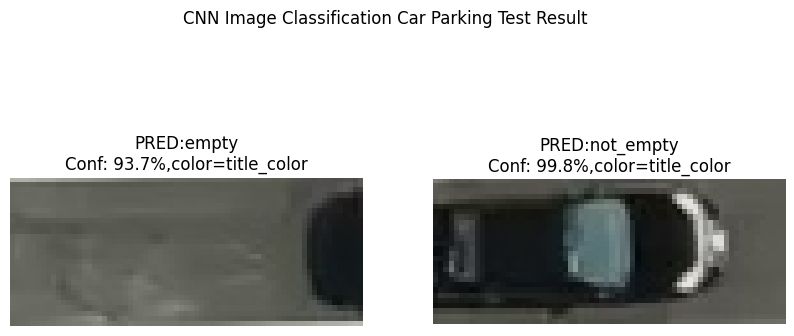

In [54]:
test_result = [
  "C:/Users/acer/python/Workshop/Parking Data/clf-data/clf-data/empty/00000010_00000335.jpg",
  "C:/Users/acer/python/Workshop/Parking Data/clf-data/clf-data/not_empty/00000000_00000148.jpg"
]

test_and_plot(test_result, model, categories)